# SVM

## Importing the libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset and removing duplicates

In [8]:
td = pd.read_csv('train_data.csv')# train
tsd =pd.read_csv('test_data.csv')# test
print(td.shape)
# td.drop_duplicates(inplace=True)
# print(td.shape)


(32561, 15)


## Cleaning the data from وجع القلب

In [9]:

# Clean all object columns in one go
def clean_dataframe(df):
    for col in df.select_dtypes(include='object').columns:
        df[col] = (df[col]
                   .str.strip()                             # remove spaces
                   .str.lower()                             # normalize case
                   .str.replace('.', '') # remove punctuation
                  )
    return df

td = clean_dataframe(td)
tsd = clean_dataframe(tsd)
td

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,state-gov,77516,bachelors,13,never-married,adm-clerical,not-in-family,white,male,2174,0,40,united-states,<=50k
1,50,self-emp-not-inc,83311,bachelors,13,married-civ-spouse,exec-managerial,husband,white,male,0,0,13,united-states,<=50k
2,38,private,215646,hs-grad,9,divorced,handlers-cleaners,not-in-family,white,male,0,0,40,united-states,<=50k
3,53,private,234721,11th,7,married-civ-spouse,handlers-cleaners,husband,black,male,0,0,40,united-states,<=50k
4,28,private,338409,bachelors,13,married-civ-spouse,prof-specialty,wife,black,female,0,0,40,cuba,<=50k
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,private,257302,assoc-acdm,12,married-civ-spouse,tech-support,wife,white,female,0,0,38,united-states,<=50k
32557,40,private,154374,hs-grad,9,married-civ-spouse,machine-op-inspct,husband,white,male,0,0,40,united-states,>50k
32558,58,private,151910,hs-grad,9,widowed,adm-clerical,unmarried,white,female,0,0,40,united-states,<=50k
32559,22,private,201490,hs-grad,9,never-married,adm-clerical,own-child,white,male,0,0,20,united-states,<=50k


## Dealing with non "None" nulls (sneaky nulls)

In [ ]:
# for col in td.columns:
#     print(f"column {col} unique values:\n {td[col].unique()}\n")
    
sneaky_nulls= ['?', 'unknown', 'N/A', 'none', 'None', '-', '']
td.replace(sneaky_nulls,np.nan, inplace=True)
tsd.replace(sneaky_nulls, np.nan, inplace=True)


new = td.dropna()
print(td.shape)
print(new.shape)
td

(32561, 15)
(30162, 15)


## Dropping Nulls and useless columns

In [ ]:
useless_columns = ['age','workclass']
new

,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,77516,bachelors,13,never-married,adm-clerical,not-in-family,white,male,2174,0,40,united-states,<=50k
1,83311,bachelors,13,married-civ-spouse,exec-managerial,husband,white,male,0,0,13,united-states,<=50k
2,215646,hs-grad,9,divorced,handlers-cleaners,not-in-family,white,male,0,0,40,united-states,<=50k
3,234721,11th,7,married-civ-spouse,handlers-cleaners,husband,black,male,0,0,40,united-states,<=50k
4,338409,bachelors,13,married-civ-spouse,prof-specialty,wife,black,female,0,0,40,cuba,<=50k
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,257302,assoc-acdm,12,married-civ-spouse,tech-support,wife,white,female,0,0,38,united-states,<=50k
32557,154374,hs-grad,9,married-civ-spouse,machine-op-inspct,husband,white,male,0,0,40,united-states,>50k
32558,151910,hs-grad,9,widowed,adm-clerical,unmarried,white,female,0,0,40,united-states,<=50k
32559,201490,hs-grad,9,never-married,adm-clerical,own-child,white,male,0,0,20,united-states,<=50k


## Splitting the dataset into the Training set and Test set


In [16]:
X =td.iloc[:,:-1]
y =td.iloc[:,-1]
X_test =tsd.iloc[:,:-1]
y_test =tsd.iloc[:,-1]

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 0)

X_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
15282,36,private,174308,11th,7,divorced,transport-moving,not-in-family,white,male,0,0,40,united-states
24870,35,private,198202,hs-grad,9,never-married,exec-managerial,not-in-family,white,female,0,0,54,united-states
18822,38,private,52963,bachelors,13,never-married,adm-clerical,not-in-family,white,female,0,0,50,united-states
26404,50,private,138270,hs-grad,9,married-civ-spouse,sales,wife,black,female,0,0,40,united-states
7842,68,self-emp-not-inc,116903,assoc-voc,11,married-civ-spouse,prof-specialty,husband,white,male,0,2149,40,united-states
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13123,43,local-gov,33331,masters,14,married-civ-spouse,exec-managerial,husband,white,male,0,0,40,united-states
19648,44,private,98466,10th,6,never-married,farming-fishing,unmarried,white,male,0,0,35,united-states
9845,23,private,45317,some-college,10,separated,sales,own-child,white,female,0,0,40,united-states
10799,45,local-gov,215862,doctorate,16,married-civ-spouse,exec-managerial,husband,white,male,7688,0,45,united-states


## Imputation (Dealing with nulls)

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

cat_cols = X_train.select_dtypes(exclude="number").columns # mode



from scipy import stats

def decide_imputation_strategy(df: pd.DataFrame, skewness_threshold: float = 1.0) -> dict:
    """
    Decides whether each numeric column should be imputed by mean or median
    based on skewness and the presence of outliers.

    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame with missing values
    skewness_threshold : float
        Absolute skewness value above which median imputation is preferred (default=1.0)

    Returns:
    --------
    dict with keys:
        'mean_columns'   : list of columns to impute with mean
        'median_columns' : list of columns to impute with median
        'strategy_report': dict with per-column details
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    mean_columns = []
    median_columns = []
    strategy_report = {}

    for col in numeric_cols:
        series = df[col].dropna()

        if series.empty:
            continue

        skewness = series.skew()
        z_scores = np.abs(stats.zscore(series))
        has_outliers = (z_scores > 3).any()

        if abs(skewness) > skewness_threshold or has_outliers:
            chosen_strategy = "median"
            median_columns.append(col)
        else:
            chosen_strategy = "mean"
            mean_columns.append(col)

        strategy_report[col] = {
            "missing_count": df[col].isna().sum(),
            "missing_pct": round(df[col].isna().mean() * 100, 2),
            "skewness": round(skewness, 4),
            "has_outliers": bool(has_outliers),
            "strategy": chosen_strategy,
        }

    return {
        "mean_columns": mean_columns,
        "median_columns": median_columns,
        "strategy_report": strategy_report,
    }


result=decide_imputation_strategy(X_train)
normal_cols =result['mean_columns']
skewed_cols =result['median_columns']
print(cat_cols)
print(normal_cols)# mean
print(skewed_cols)# median

imputer = ColumnTransformer(transformers=[
    ('cat', SimpleImputer(strategy='most_frequent'), cat_cols),
    ('avg', SimpleImputer(strategy='mean'),        normal_cols),
    ('med', SimpleImputer(strategy='median'),        skewed_cols)
    
], remainder='passthrough')

imputer.set_output(transform="pandas")

X_train =imputer.fit_transform(X_train)
X_val =imputer.transform(X_val)
X_test =imputer.transform(X_test)

X_train

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')
[]
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


,cat__workclass,cat__education,cat__marital-status,cat__occupation,cat__relationship,cat__race,cat__sex,cat__native-country,med__age,med__fnlwgt,med__education-num,med__capital-gain,med__capital-loss,med__hours-per-week
15282,private,11th,divorced,transport-moving,not-in-family,white,male,united-states,36.0,174308.0,7.0,0.0,0.0,40.0
24870,private,hs-grad,never-married,exec-managerial,not-in-family,white,female,united-states,35.0,198202.0,9.0,0.0,0.0,54.0
18822,private,bachelors,never-married,adm-clerical,not-in-family,white,female,united-states,38.0,52963.0,13.0,0.0,0.0,50.0
26404,private,hs-grad,married-civ-spouse,sales,wife,black,female,united-states,50.0,138270.0,9.0,0.0,0.0,40.0
7842,self-emp-not-inc,assoc-voc,married-civ-spouse,prof-specialty,husband,white,male,united-states,68.0,116903.0,11.0,0.0,2149.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13123,local-gov,masters,married-civ-spouse,exec-managerial,husband,white,male,united-states,43.0,33331.0,14.0,0.0,0.0,40.0
19648,private,10th,never-married,farming-fishing,unmarried,white,male,united-states,44.0,98466.0,6.0,0.0,0.0,35.0
9845,private,some-college,separated,sales,own-child,white,female,united-states,23.0,45317.0,10.0,0.0,0.0,40.0
10799,local-gov,doctorate,married-civ-spouse,exec-managerial,husband,white,male,united-states,45.0,215862.0,16.0,7688.0,0.0,45.0


## Encoding 

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# print(X_train.columns)

nominal_cols = ['cat__Gender', 'cat__work_type', 'cat__smoking_status']
ordinal_cols = [] #label 

# --- One-Hot Encode nominal ---
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first') ## drop first if Logistic or SVM otherwise remove it
ohe.fit(X_train[nominal_cols])

for split_X  in [X_train, X_val, X_test]:
    encoded = ohe.transform(split_X[nominal_cols])
    encoded_df = pd.DataFrame(encoded,
                              columns=ohe.get_feature_names_out(nominal_cols),
                              index=split_X.index)
    split_X.drop(columns=nominal_cols, inplace=True)
    split_X[encoded_df.columns] = encoded_df

# --- Label Encode ordinal for features (X) ---
label_encoders = {}
for col in ordinal_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])
    X_val[col]   = le.transform(X_val[col])
    label_encoders[col] = le

# --- Label Encode target Y ---
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val   = le.transform(y_val)
y_test  = le.transform(y_test)

y_train

array([0, 0, 0, ..., 0, 1, 0])

## Feature Scaling (not for decision trees/random forests)

In [22]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_val = sc.transform(X_val)
X_test = sc.transform(X_test)
X_train

array([[-0.18928087, -0.14399738, -1.19288369, ...,  0.30418053,
        -0.04429181, -0.02234564],
       [-0.26265957,  0.08271497, -0.41510561, ...,  0.30418053,
        -0.04429181, -0.02234564],
       [-0.04252347, -1.2953496 ,  1.14045055, ...,  0.30418053,
        -0.04429181, -0.02234564],
       ...,
       [-1.14320394, -1.36789679, -0.02621657, ...,  0.30418053,
        -0.04429181, -0.02234564],
       [ 0.47112741,  0.25027755,  2.30711767, ...,  0.30418053,
        -0.04429181, -0.02234564],
       [-0.99644654, -0.02428407, -0.02621657, ...,  0.30418053,
        -0.04429181, -0.02234564]])

## Training the SVM on the Training set

--- Validation Phase (Tuning Hyperparameters) ---
Tested C=0.1, kernel='linear' -> Validation F1: 0.7784
Tested C=1.0, kernel='linear' -> Validation F1: 0.7781
Tested C=0.1, kernel='rbf' -> Validation F1: 0.7434
Tested C=1.0, kernel='rbf' -> Validation F1: 0.7677
Tested C=10.0, kernel='rbf' -> Validation F1: 0.7698

Best Hyperparameters found: {'C': 0.1, 'kernel': 'linear'} with Validation F1: 0.7784

--- Final Evaluation on Test Set ---
Test Accuracy:  0.8525
Test Precision: 0.8454
Test Recall:    0.8525
Test F1 Score:  0.8460
Confusion Matrix:
[[11645   790]
 [ 1612  2234]]


C:\Users\sansn\AppData\Local\Temp\ipykernel_864\4064988558.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=param_labels, y=val_f1_scores, palette="viridis")


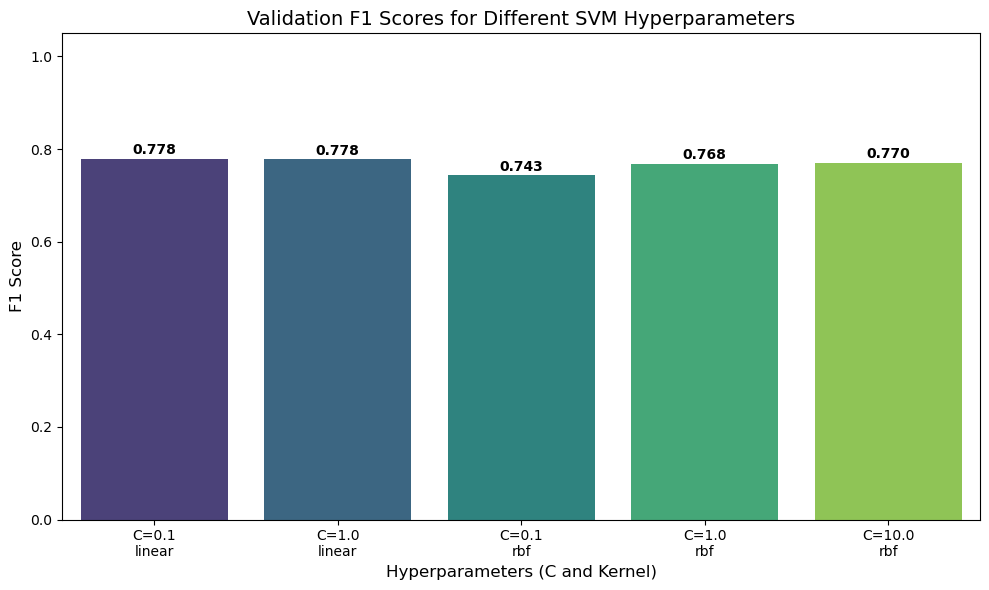

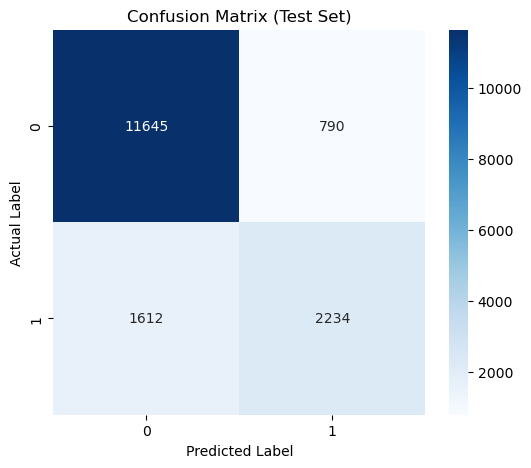

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix

# 1. Define the 5 hyperparameter combinations to test
hyperparameters = [
    {'C': 0.1, 'kernel': 'linear'},
    {'C': 1.0, 'kernel': 'linear'},
    {'C': 0.1, 'kernel': 'rbf'},
    {'C': 1.0, 'kernel': 'rbf'},
    {'C': 10.0, 'kernel': 'rbf'}
]

# Lists to store results for plotting
val_f1_scores = []
param_labels = []

best_f1 = -1
best_params = None

print("--- Validation Phase (Tuning Hyperparameters) ---")

# 2. Iterate through hyperparameters, train on Train, evaluate on Val
for params in hyperparameters:
    # Initialize SVM with current parameters
    svm = SVC(C=params['C'], kernel=params['kernel'], random_state=42)
    
    # Train on training data
    svm.fit(X_train, y_train)
    
    # Predict on validation data
    y_val_pred = svm.predict(X_val)
    
    # Calculate F1 score (assuming binary classification; use average='macro' or 'weighted' if multiclass)
    current_f1 = f1_score(y_val, y_val_pred, average='macro') 
    val_f1_scores.append(current_f1)
    
    # Create a string label for the plot
    label = f"C={params['C']}\n{params['kernel']}"
    param_labels.append(label)
    
    print(f"Tested C={params['C']}, kernel='{params['kernel']}' -> Validation F1: {current_f1:.4f}")
    
    # Update best parameters if current is better
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_params = params

print(f"\nBest Hyperparameters found: {best_params} with Validation F1: {best_f1:.4f}\n")

# 3. Train final model with the best hyperparameters
print("--- Final Evaluation on Test Set ---")
final_svm = SVC(C=best_params['C'], kernel=best_params['kernel'], random_state=42)

# Note: Sometimes people combine X_train and X_val here for more training data, 
# but strictly following your split, we will train on X_train.
final_svm.fit(X_train, y_train)

# 4. Evaluate on the Test set
y_test_pred = final_svm.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_test_pred)

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1 Score:  {test_f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# 5. Plot comparing the different hyperparameters and their F1 scores
plt.figure(figsize=(10, 6))
sns.barplot(x=param_labels, y=val_f1_scores, palette="viridis")

# Formatting the plot
plt.title('Validation F1 Scores for Different SVM Hyperparameters', fontsize=14)
plt.xlabel('Hyperparameters (C and Kernel)', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, 1.05) # Assuming F1 max is 1.0

# Add text labels on top of the bars
for i, v in enumerate(val_f1_scores):
    plt.text(i, v + 0.01, f"{v:.3f}", color='black', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Optional: Plot the confusion matrix nicely
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


## Hyperparameter Tuning for Logistic Regression
In this section, we will tune the hyperparameter `C` for the Logistic Regression model using the validation set, and then evaluate the best model on the test set.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# 1. Define 5 different values of C to test
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]

# Storage for results
val_f1_scores = []
param_labels = []

best_f1 = -1
best_C = None

print("=" * 60)
print("  Logistic Regression — Validation Phase (Tuning C)")
print("=" * 60)

# 2. Train on X_train, evaluate on X_val for each C
for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)

    y_val_pred = lr.predict(X_val)
    current_f1 = f1_score(y_val, y_val_pred, average="macro")

    val_f1_scores.append(current_f1)
    param_labels.append(f"C={C}")

    print(f"  C={C:<8} -> Validation F1 (macro): {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_C = C

print(f"\n✔ Best C = {best_C}  (Validation F1: {best_f1:.4f})\n")

: 

## Evaluation and Plots
Evaluating the best Logistic Regression model on the test set and plotting the F1 scores across different `C` values.

In [ ]:
# 3. Train final model with best C on X_train, evaluate on X_test
print("=" * 60)
print("  Final Evaluation on Test Set")
print("=" * 60)

final_lr = LogisticRegression(C=best_C, max_iter=1000, random_state=42)
final_lr.fit(X_train, y_train)

y_test_pred = final_lr.predict(X_test)

test_accuracy  = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average="weighted")
test_recall    = recall_score(y_test, y_test_pred, average="weighted")
test_f1        = f1_score(y_test, y_test_pred, average="weighted")
conf_matrix    = confusion_matrix(y_test, y_test_pred)

print(f"  Accuracy : {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall   : {test_recall:.4f}")
print(f"  F1 Score : {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:")
print(conf_matrix)

# 4. Plot — F1 scores across C values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart of validation F1 by C ---
colors = ["#2ecc71" if c == best_C else "#3498db" for c in C_values]
bars = axes[0].bar(param_labels, val_f1_scores, color=colors, edgecolor="black")

for bar, score in zip(bars, val_f1_scores):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{score:.4f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=10,
    )

axes[0].set_title(
    "Logistic Regression — Validation F1 Score per C",
    fontsize=14,
    fontweight="bold",
)
axes[0].set_xlabel("Regularization Parameter (C)", fontsize=12)
axes[0].set_ylabel("F1 Score (macro)", fontsize=12)
axes[0].set_ylim(0, 1.05)
axes[0].legend(
    [plt.Rectangle((0, 0), 1, 1, fc="#2ecc71"), plt.Rectangle((0, 0), 1, 1, fc="#3498db")],
    ["Best C", "Other"],
    loc="lower right",
)

# --- Confusion matrix heatmap ---
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix (Test Set)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Actual Label", fontsize=12)
axes[1].set_xlabel("Predicted Label", fontsize=12)

plt.tight_layout()
plt.show()

## Hyperparameter Tuning for Decision Tree
In this section we tune `max_depth` for the Decision Tree classifier.  
We test 5 different values using the validation set, pick the best one via **macro F1**, then evaluate the final model on the test set.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score,
    recall_score, confusion_matrix, classification_report,
)

# 1. Define 5 different max_depth values to test
max_depth_values = [3, 5, 10, 15, 20]

# Storage for results
dt_val_f1_scores = []
dt_param_labels  = []

dt_best_f1    = -1
dt_best_depth = None

print("=" * 60)
print("  Decision Tree — Validation Phase (Tuning max_depth)")
print("=" * 60)

# 2. Train on X_train, evaluate on X_val for each max_depth
for depth in max_depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    y_val_pred  = dt.predict(X_val)
    current_f1  = f1_score(y_val, y_val_pred, average="macro")

    dt_val_f1_scores.append(current_f1)
    dt_param_labels.append(f"depth={depth}")

    print(f"  max_depth={depth:<4} → Validation F1 (macro): {current_f1:.4f}")

    if current_f1 > dt_best_f1:
        dt_best_f1    = current_f1
        dt_best_depth = depth

print(f"\n✔ Best max_depth = {dt_best_depth}  (Validation F1: {dt_best_f1:.4f})\n")

## Decision Tree — Evaluation and Plots
Evaluating the best Decision Tree model on the test set and plotting the F1 scores across different `max_depth` values.

In [ ]:
# 3. Train final model with best max_depth on X_train, evaluate on X_test
print("=" * 60)
print("  Decision Tree — Final Evaluation on Test Set")
print("=" * 60)

final_dt = DecisionTreeClassifier(max_depth=dt_best_depth, random_state=42)
final_dt.fit(X_train, y_train)

y_test_pred = final_dt.predict(X_test)

dt_test_accuracy  = accuracy_score(y_test, y_test_pred)
dt_test_precision = precision_score(y_test, y_test_pred, average="weighted")
dt_test_recall    = recall_score(y_test, y_test_pred, average="weighted")
dt_test_f1        = f1_score(y_test, y_test_pred, average="weighted")
dt_conf_matrix    = confusion_matrix(y_test, y_test_pred)

print(f"  Accuracy : {dt_test_accuracy:.4f}")
print(f"  Precision: {dt_test_precision:.4f}")
print(f"  Recall   : {dt_test_recall:.4f}")
print(f"  F1 Score : {dt_test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:")
print(dt_conf_matrix)

# 4. Plot — F1 scores across max_depth values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart of validation F1 by max_depth ---
dt_colors = ["#2ecc71" if d == dt_best_depth else "#3498db" for d in max_depth_values]
bars = axes[0].bar(dt_param_labels, dt_val_f1_scores, color=dt_colors, edgecolor="black")

for bar, score in zip(bars, dt_val_f1_scores):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{score:.4f}",
        ha="center", va="bottom", fontweight="bold", fontsize=10,
    )

axes[0].set_title("Decision Tree — Validation F1 Score per max_depth",
                   fontsize=14, fontweight="bold")
axes[0].set_xlabel("max_depth", fontsize=12)
axes[0].set_ylabel("F1 Score (macro)", fontsize=12)
axes[0].set_ylim(0, 1.05)
axes[0].legend(
    [plt.Rectangle((0, 0), 1, 1, fc="#2ecc71"),
     plt.Rectangle((0, 0), 1, 1, fc="#3498db")],
    ["Best max_depth", "Other"], loc="lower right",
)

# --- Confusion matrix heatmap ---
sns.heatmap(dt_conf_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix (Test Set)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Actual Label", fontsize=12)
axes[1].set_xlabel("Predicted Label", fontsize=12)

plt.tight_layout()
plt.show()

## Hyperparameter Tuning for Random Forest
In this section we tune `max_depth` and `n_estimators` for the Random Forest classifier.  
We test 5 different combinations using the validation set, pick the best one via **macro F1**, then evaluate the final model on the test set.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score,
    recall_score, confusion_matrix, classification_report,
)

# 1. Define 5 different (n_estimators, max_depth) combinations to test
rf_hyperparameters = [
    {"n_estimators": 50,  "max_depth": 5},
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 100, "max_depth": 20},
    {"n_estimators": 200, "max_depth": 10},
    {"n_estimators": 200, "max_depth": 20},
]

# Storage for results
rf_val_f1_scores = []
rf_param_labels  = []

rf_best_f1     = -1
rf_best_params = None

print("=" * 65)
print("  Random Forest — Validation Phase (Tuning n_estimators & max_depth)")
print("=" * 65)

# 2. Train on X_train, evaluate on X_val for each combination
for params in rf_hyperparameters:
    rf = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)

    y_val_pred = rf.predict(X_val)
    current_f1 = f1_score(y_val, y_val_pred, average="macro")

    rf_val_f1_scores.append(current_f1)
    label = f"n={params['n_estimators']}\ndepth={params['max_depth']}"
    rf_param_labels.append(label)

    print(
        f"  n_estimators={params['n_estimators']:<4} max_depth={params['max_depth']:<4} "
        f"→ Validation F1 (macro): {current_f1:.4f}"
    )

    if current_f1 > rf_best_f1:
        rf_best_f1     = current_f1
        rf_best_params = params

print(f"\n✔ Best params: {rf_best_params}  (Validation F1: {rf_best_f1:.4f})\n")

## Random Forest — Evaluation and Plots
Evaluating the best Random Forest model on the test set and plotting the F1 scores across the different hyperparameter combinations.

In [ ]:
# 3. Train final model with best params on X_train, evaluate on X_test
print("=" * 60)
print("  Random Forest — Final Evaluation on Test Set")
print("=" * 60)

final_rf = RandomForestClassifier(
    n_estimators=rf_best_params["n_estimators"],
    max_depth=rf_best_params["max_depth"],
    random_state=42,
    n_jobs=-1,
)
final_rf.fit(X_train, y_train)

y_test_pred = final_rf.predict(X_test)

rf_test_accuracy  = accuracy_score(y_test, y_test_pred)
rf_test_precision = precision_score(y_test, y_test_pred, average="weighted")
rf_test_recall    = recall_score(y_test, y_test_pred, average="weighted")
rf_test_f1        = f1_score(y_test, y_test_pred, average="weighted")
rf_conf_matrix    = confusion_matrix(y_test, y_test_pred)

print(f"  Accuracy : {rf_test_accuracy:.4f}")
print(f"  Precision: {rf_test_precision:.4f}")
print(f"  Recall   : {rf_test_recall:.4f}")
print(f"  F1 Score : {rf_test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))
print("Confusion Matrix:")
print(rf_conf_matrix)

# 4. Plot — F1 scores across hyperparameter combinations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart of validation F1 ---
rf_colors = [
    "#2ecc71" if (p["n_estimators"] == rf_best_params["n_estimators"]
                  and p["max_depth"] == rf_best_params["max_depth"])
    else "#3498db"
    for p in rf_hyperparameters
]
bars = axes[0].bar(rf_param_labels, rf_val_f1_scores, color=rf_colors, edgecolor="black")

for bar, score in zip(bars, rf_val_f1_scores):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{score:.4f}",
        ha="center", va="bottom", fontweight="bold", fontsize=10,
    )

axes[0].set_title("Random Forest — Validation F1 Score per Hyperparameter Combo",
                   fontsize=13, fontweight="bold")
axes[0].set_xlabel("(n_estimators, max_depth)", fontsize=12)
axes[0].set_ylabel("F1 Score (macro)", fontsize=12)
axes[0].set_ylim(0, 1.05)
axes[0].legend(
    [plt.Rectangle((0, 0), 1, 1, fc="#2ecc71"),
     plt.Rectangle((0, 0), 1, 1, fc="#3498db")],
    ["Best Combo", "Other"], loc="lower right",
)

# --- Confusion matrix heatmap ---
sns.heatmap(rf_conf_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix (Test Set)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Actual Label", fontsize=12)
axes[1].set_xlabel("Predicted Label", fontsize=12)

plt.tight_layout()
plt.show()